In [1]:
from resources.imports import *

import torch
import torch.nn as nn

from resources.MLdata import DATA
from resources.MLfunc import CustomQuantileLoss, CustomQuantileLossMATLAB, EarlyStopping, weights_init
from resources.MLmodels import MODEL, MLP

# Stress-Strain Curve

In [3]:
DAT = DATA(
    path=0, 
    path_add="",
    load=True, 
    LAT="FCC", 
    dis="disNodes", 
    dN=0.2, 
    mechMode="UT",
    scale=("minmax", "in")
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

c:\Users\exy053\OneDrive - Queen Mary, University of London\Documents\Research\p1-LatticeFractureToughness\p1git-Lattices\code\resources\lattices.py:637: RuntimeWarning: divide by zero encountered in double_scalars
  return np.array([np.cos(np.arctan([n0[1]/n0[0]]))[0], np.sin(np.arctan([n0[1]/n0[0]]))[0]])


Using device: cpu


In [6]:
DAT.UT_train_in.shape, DAT.UT_train_out.shape

((3584, 714), (3584, 201))

In [7]:
print("Train - in (min, max), out (min, max):", DAT.UT_train_in.min(), DAT.UT_train_in.max(), DAT.UT_train_out.min(), DAT.UT_train_out.max())
print("Val   - in (min, max), out (min, max):", DAT.UT_val_in.min(), DAT.UT_val_in.max(), DAT.UT_val_out.min(), DAT.UT_val_out.max())
print("Test  - in (min, max), out (min, max):", DAT.UT_test_in.min(), DAT.UT_test_in.max(), DAT.UT_test_out.min(), DAT.UT_test_out.max(), "\n")

Train - in (min, max), out (min, max): 0.0 1.0000000000000002 -7.30444409064 5.09082527696
Val   - in (min, max), out (min, max): -0.0013022672212396058 1.002277703218239 -6.668491038944001 5.014220287272
Test  - in (min, max), out (min, max): -0.001779465178217754 1.0024366556229671 -6.897249815776 5.014220287272 



In [10]:
MLP1 = MODEL(
    typ="MLP",
    model=MLP(in_size=DAT.UT_train_in.shape[-1], 
              h_size=[4096, 2048, 1024, 1024, 1024, 512, 512], 
              out_size=DAT.UT_train_out.shape[-1], 
              act="relu",
              block="mlp",
              norm="batch", 
              dropout=0.0).to(device), 
    lossf = CustomQuantileLossMATLAB(quantiles=[0.5, 0.45, 0.1], zone_boundaries=(67, 134), err_type="L2"),
    opt=("adam", 6.016e-6), #("adam", 1e-4),
    batch=16,
    lr=9e-4,
    data=DAT,
    mechMode="UT",
    scheduler=None, #("min", 0.2427, 18, 1e-4), 
    earlyStop=EarlyStopping(patience=100, min_delta=1e-4, verbose=True),
    w_init=weights_init,
    device=device
)

MLP1._summary()

Layer (type:depth-idx)                   Output Shape              Param #
MLP                                      [16, 201]                 --
├─Linear: 1-1                            [16, 4096]                2,928,640
├─BatchNorm1d: 1-2                       [16, 4096]                8,192
├─ReLU: 1-3                              [16, 4096]                --
├─ModuleList: 1-4                        --                        --
│    └─mlpBlock: 2-1                     [16, 2048]                --
│    │    └─Linear: 3-1                  [16, 2048]                8,390,656
│    │    └─BatchNorm1d: 3-2             [16, 2048]                4,096
│    │    └─ReLU: 3-3                    [16, 2048]                --
│    └─mlpBlock: 2-2                     [16, 1024]                --
│    │    └─Linear: 3-4                  [16, 1024]                2,098,176
│    │    └─BatchNorm1d: 3-5             [16, 1024]                2,048
│    │    └─ReLU: 3-6                    [16, 1024]    

 -> Epoch 1/1000 || LOSS - train: 24.513879, val: 19.538491 | MSE - train: 0.953217, val: 0.739313 | RMSE - train: 0.976328, val: 0.859833 | LR: 9.00e-04
 -> Epoch 20/1000 || LOSS - train: 5.125615, val: 20.669360 | MSE - train: 0.224125, val: 0.770614 | RMSE - train: 0.473418, val: 0.877846 | LR: 9.00e-04
 -> Epoch 40/1000 || LOSS - train: 3.564955, val: 21.993068 | MSE - train: 0.167500, val: 0.814280 | RMSE - train: 0.409268, val: 0.902375 | LR: 9.00e-04
 -> Epoch 60/1000 || LOSS - train: 2.372050, val: 22.437577 | MSE - train: 0.122864, val: 0.832744 | RMSE - train: 0.350519, val: 0.912548 | LR: 9.00e-04
 -> Epoch 80/1000 || LOSS - train: 1.919102, val: 22.086162 | MSE - train: 0.103995, val: 0.821540 | RMSE - train: 0.322483, val: 0.906388 | LR: 9.00e-04
 -> Epoch 100/1000 || LOSS - train: 1.531463, val: 22.776614 | MSE - train: 0.088665, val: 0.848050 | RMSE - train: 0.297767, val: 0.920897 | LR: 9.00e-04
 !!! Early stopping triggered after 100 epochs without improvement !!!
====

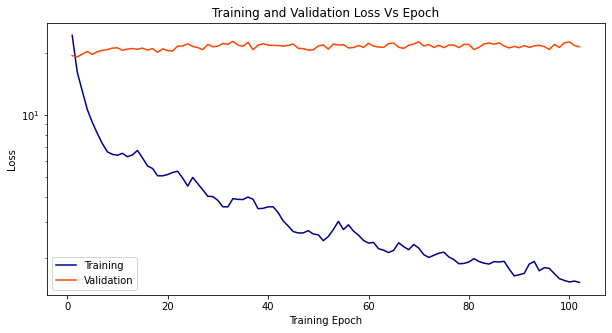

In [11]:
MLP1.train(n_epochs=1000, verbose=20, plot=True)

Best prediction: 663, Worst prediction: 2052


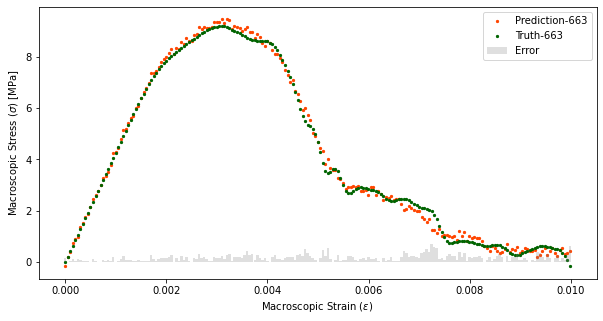

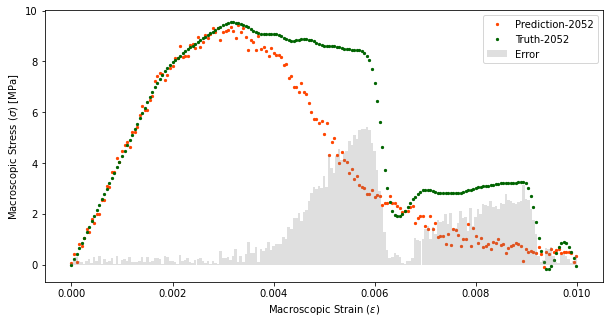

In [12]:
MLP1.predict(test_dataloader=MLP1.UT_train_dataloader, plot=True)